In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('CDC_Wastewater_Data_for_Influenza_A.csv', low_memory=False)

df['grip_durumu'] = (df['pcr_target_avg_conc'] > 0).astype(int)
y = df['grip_durumu']

X = df[['population_served']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print(f"Eğitim (Çalışma) seti boyutu: {len(X_train)} satır")
print(f"Test (Sınav) seti boyutu: {len(X_test)} satır")

Eğitim (Çalışma) seti boyutu: 148680 satır
Test (Sınav) seti boyutu: 63721 satır


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(random_state=42)
knn_model = KNeighborsClassifier()
lr_model = LogisticRegression(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

rf_model.fit(X_train, y_train)
knn_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

rf_tahminler = rf_model.predict(X_test)
knn_tahminler = knn_model.predict(X_test)
lr_tahminler = lr_model.predict(X_test)
gb_tahminler = gb_model.predict(X_test)

rf_basari = accuracy_score(y_test, rf_tahminler) *100
knn_basari = accuracy_score(y_test, knn_tahminler) *100
lr_basari = accuracy_score(y_test, lr_tahminler) * 100
gb_basari = accuracy_score(y_test, gb_tahminler) * 100

print(f"Random Forest Doğruluk Oranı (Accuracy): %{rf_basari:.2f}")
print(f"k-NN Doğruluk Oranı (Accuracy): %{knn_basari:.2f}")
print(f"Lojistik Regresyon Doğruluk Oranı: %{lr_basari:.2f}")
print(f"Gradient Boosting Doğruluk Oranı: %{gb_basari:.2f}")

print(f"Modellerin boş hali oluşturuldu, eğitildi, test verisi üzerindeki tahminleri tamamlandı!! ")

Random Forest Doğruluk Oranı (Accuracy): %62.93
k-NN Doğruluk Oranı (Accuracy): %57.68
Lojistik Regresyon Doğruluk Oranı: %58.87
Gradient Boosting Doğruluk Oranı: %60.72
Modellerin boş hali oluşturuldu, eğitildi, test verisi üzerindeki tahminleri tamamlandı!! 


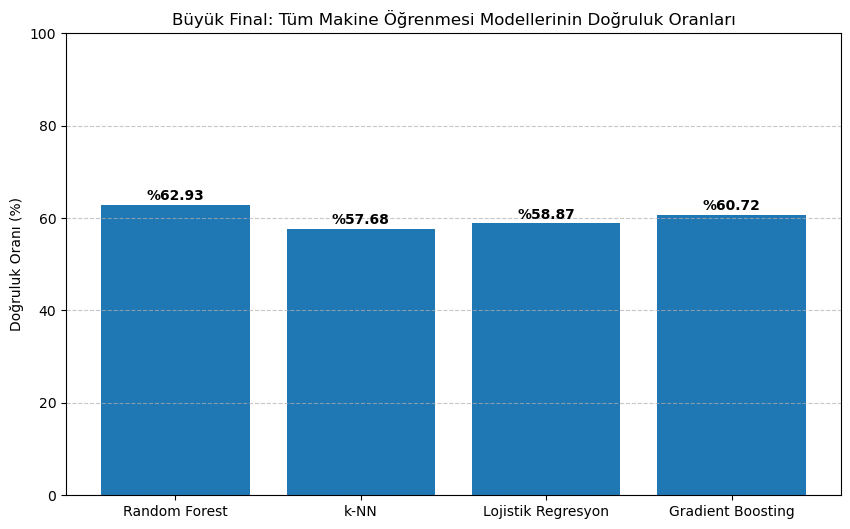

In [8]:
import matplotlib.pyplot as plt

skorlar = [rf_basari , knn_basari, lr_basari, gb_basari]
model_adlari = ['Random Forest', 'k-NN', 'Lojistik Regresyon', 'Gradient Boosting']

plt.figure(figsize=(10, 6)) 
plt.bar(model_adlari, skorlar)
plt.title('Büyük Final: Tüm Makine Öğrenmesi Modellerinin Doğruluk Oranları')
plt.ylabel('Doğruluk Oranı (%)')
plt.ylim(0, 100) 
plt.grid(axis='y', linestyle='--', alpha=0.7) 

for i, skor in enumerate(skorlar):
    plt.text(i, skor + 1, f'%{skor:.2f}', ha='center', fontweight='bold')

plt.show()

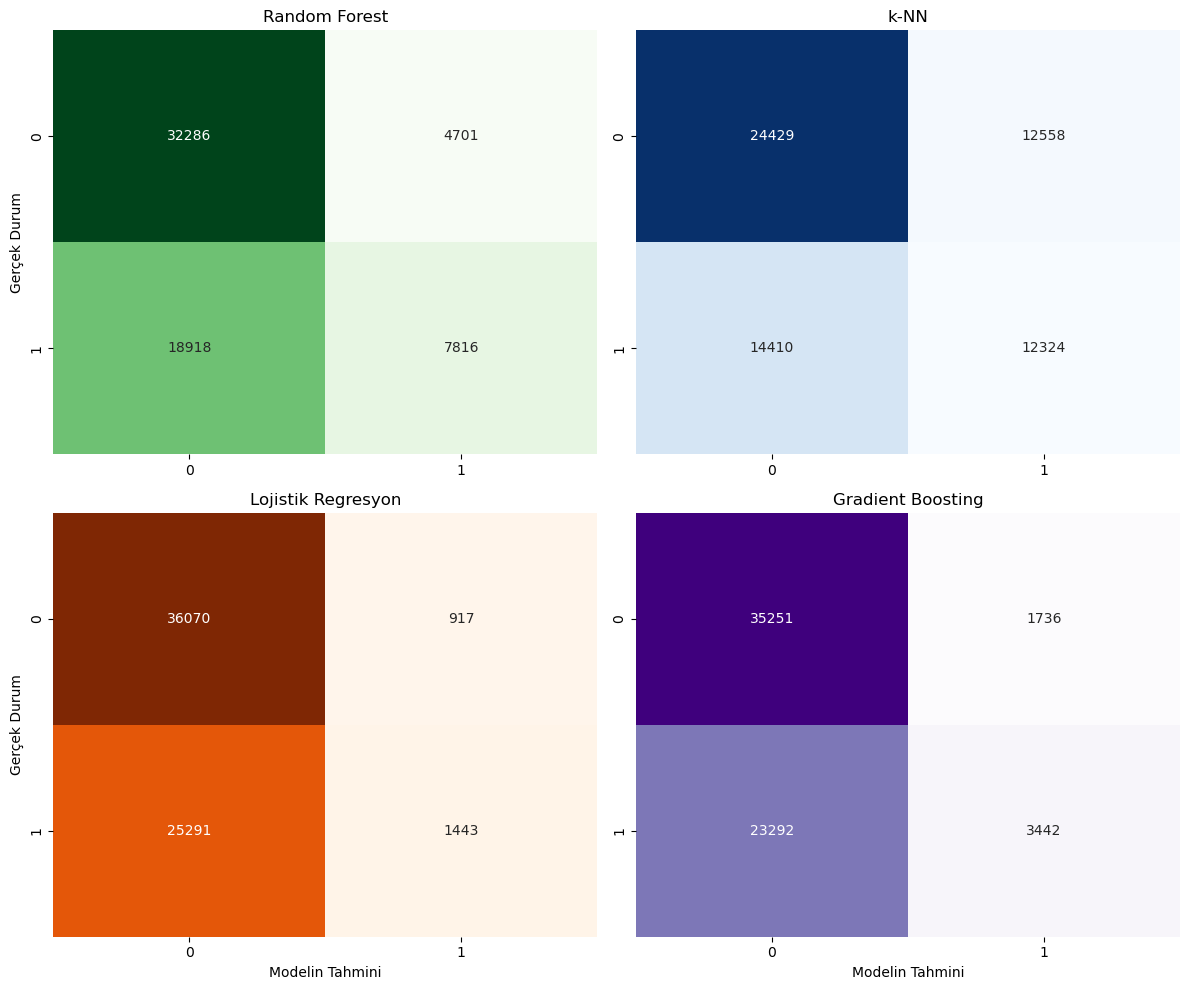

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, rf_tahminler)
cm_knn = confusion_matrix(y_test, knn_tahminler)
cm_lr = confusion_matrix(y_test, lr_tahminler)
cm_gb = confusion_matrix(y_test, gb_tahminler)

fig, ax = plt.subplots(2, 2, figsize=(12, 10))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax[0, 0])
ax[0, 0].set_title('Random Forest')
ax[0, 0].set_ylabel('Gerçek Durum')

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax[0, 1])
ax[0, 1].set_title('k-NN')

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=ax[1, 0])
ax[1, 0].set_title('Lojistik Regresyon')
ax[1, 0].set_xlabel('Modelin Tahmini')
ax[1, 0].set_ylabel('Gerçek Durum')

sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Purples', cbar=False, ax=ax[1, 1])
ax[1, 1].set_title('Gradient Boosting')
ax[1, 1].set_xlabel('Modelin Tahmini')

plt.tight_layout()
plt.show()

In [10]:
# Bu Influenza tespit veri setinde kullandığımız 4 algoritma (Random Forest, 
# k-NN, Lojistik Regresyon ve Gradient Boosting) arasında en yüksek 
# doğruluk oranına Random Forest algoritması sahip oldu. Random Forest'ın 
# ensemble (topluluk) öğrenme yapısı, atık su verisindeki karmaşık ilişkileri 
# diğer modellere kıyasla doğru bir şekilde çözmüştür.